# Cats vs Dogs: MLflow + MinIO tracked training

This notebook is the experiment interface. Reusable implementation lives in
`cats_dogs_pipeline.py`; the notebook configures a run group, invokes the pipeline, records
the standard experiments, and can optionally launch history-aware auto-tuning.

The MLflow Tracking Server proxies all Artifact writes to MinIO. No MinIO credential belongs in
this notebook or in the client process.


## 1. Load the reusable pipeline

Restart the kernel after changing `cats_dogs_pipeline.py` so the notebook imports a clean module.


In [1]:
import sys
from dataclasses import asdict, replace
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

MODULE_DIR = Path.cwd()
if not (MODULE_DIR / "cats_dogs_pipeline.py").is_file():
    MODULE_DIR = Path(
        "/data/ai/chenzhangyue/code/train/train-model/cats-and-dogs"
    )
if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))

from cats_dogs_pipeline import (
    PipelineConfig,
    build_model,
    compare_run_group,
    create_generators,
    plot_confusion_matrix,
    plot_dataset_distribution,
    plot_gradcam_examples,
    plot_image_batch,
    plot_prediction_examples,
    plot_training_history,
    preflight_tracking,
    prepare_dataset,
    run_tracked_training,
)
from cats_dogs_tuner import TuningConfig, run_auto_tuning


/data/conda/envs/attend-ray-py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
I0000 00:00:1785412233.182615 1274941 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785412233.222769 1274941 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785412234.288764 1274941 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical

## 2. Configure tracking and fail closed

Change `EPOCHS` and the optional tuning parameters in the next cell before running training.
The cell is tagged `parameters` for automation tools such as Papermill.

The preflight verifies MLflow connectivity and rejects a local Artifact Store. With the repository's
service configuration, `mlflow-artifacts:/` is proxied by MLflow Server to `s3://mlflow-artifacts`
in MinIO.


In [ ]:
# Change these values before running the notebook.
EPOCHS = None  # None uses CATS_DOGS_EPOCHS (default: 1); set 10 for ten epochs.
RUN_AUTO_TUNING = True
TUNER_EPOCHS = 32
TUNER_MAX_TRIALS = 8
TUNER_TARGET_VAL_ACCURACY = 0.95

config = PipelineConfig.from_env()
if EPOCHS is not None:
    config = replace(config, epochs=EPOCHS)
tracking = preflight_tracking(config)

display(pd.Series({
    "tracking_uri": config.tracking_uri,
    "experiment": tracking.experiment_name,
    "experiment_id": tracking.experiment_id,
    "artifact_location": tracking.artifact_location,
    "run_group_id": config.run_group_id,
    "epochs": config.epochs,
    "run_auto_tuning": RUN_AUTO_TUNING,
    "tuner_epochs": TUNER_EPOCHS,
    "tuner_max_trials": TUNER_MAX_TRIALS,
    "tuner_target_val_accuracy": TUNER_TARGET_VAL_ACCURACY,
    "quality_gate_min_accuracy": config.min_test_accuracy,
}))


## 3. Prepare and review the immutable input

Preparation validates every image, calculates SHA-256 checksums, creates deterministic train,
validation, and test splits, and writes the Manifest later logged as MLflow Dataset Inputs.


/data/conda/envs/attend-ray-py312/lib/python3.12/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


dataset_version                              sha256-b17077327cf872b4
source_uri         file:///data/ai/chenzhangyue/code/data/cats-an...
content_sha256     b17077327cf872b4dff77102d6e5463f97053445c7e7e2...
split_sha256       49674d899e08644612fd823607099050e3ca77be3961c2...
valid_images                                                   24998
invalid_images                                                     0
dtype: object

class_name,Cat,Dog
split,,
test,625,625
training,11249,11249
validation,625,625


[]

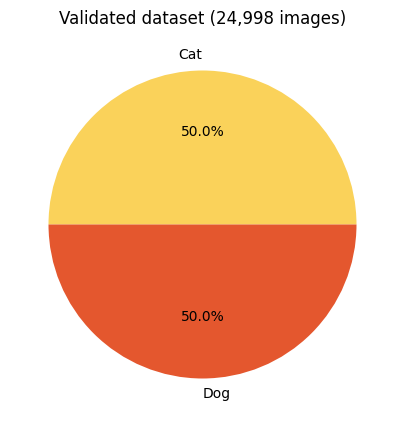

In [3]:
dataset = prepare_dataset(config)

display(pd.Series({
    "dataset_version": dataset.dataset_version,
    "source_uri": dataset.source_uri,
    "content_sha256": dataset.content_digest,
    "split_sha256": dataset.split_digest,
    "valid_images": len(dataset.manifest),
    "invalid_images": len(dataset.invalid_files),
}))
display(dataset.split_counts)
display(dataset.invalid_files)
plot_dataset_distribution(dataset)
plt.show()


## 4. Baseline Run


Found 22498 images belonging to 2 classes.
Found 1250 images belonging to 2 classes.
Found 1250 images belonging to 2 classes.


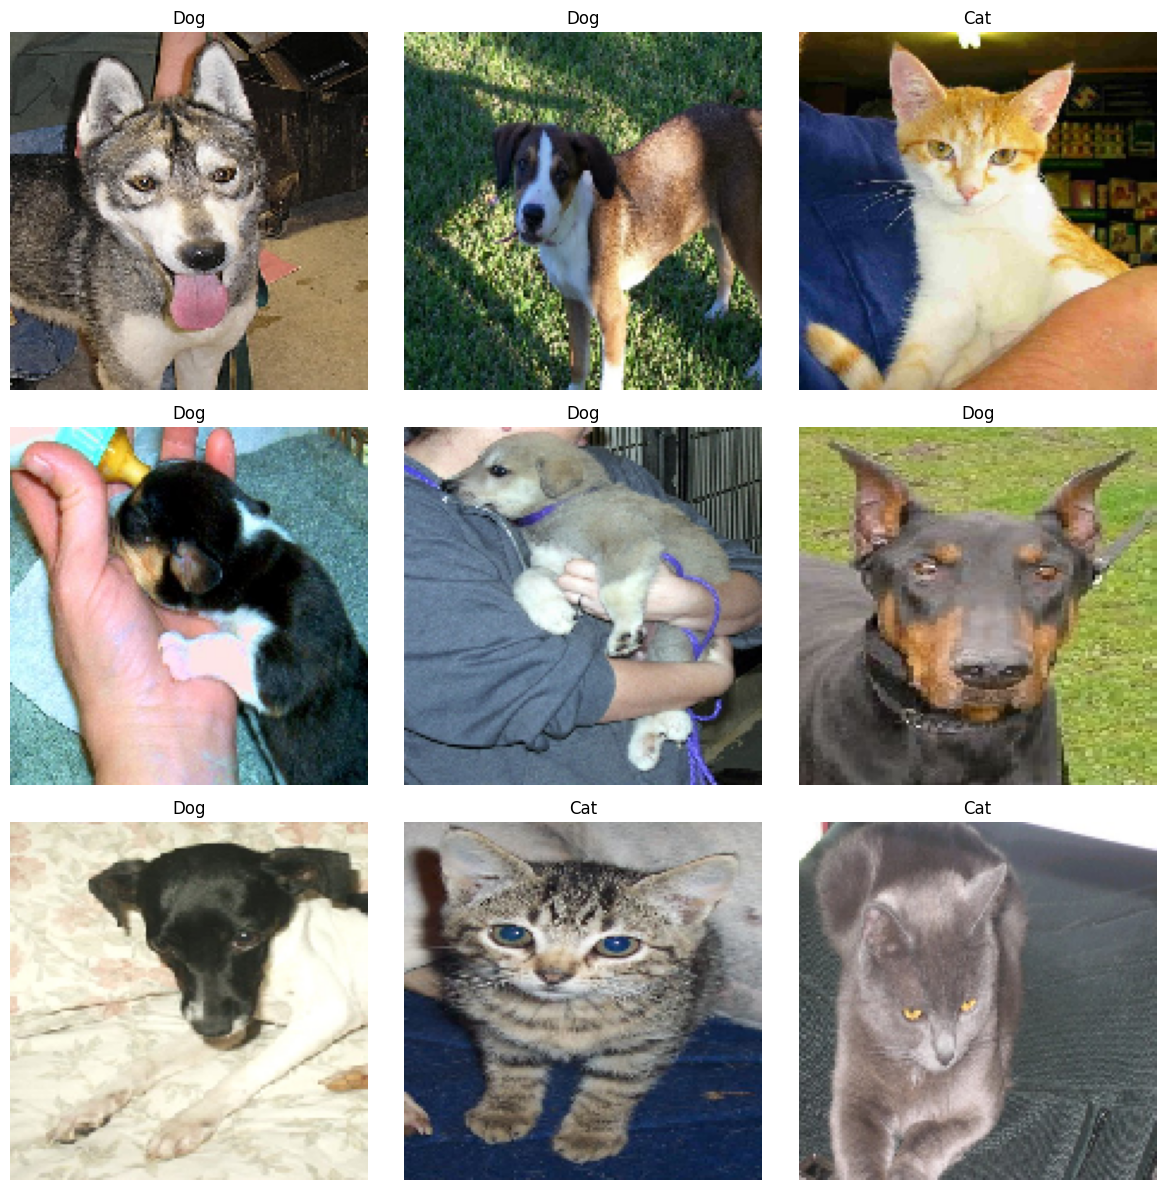

In [4]:
baseline_data = create_generators(config, dataset, augmented=False)
plot_image_batch(baseline_data.training, n_images=9)
plt.show()


In [ ]:
baseline_model = build_model(config, variant="baseline")
baseline_result = run_tracked_training(
    config,
    tracking,
    dataset,
    baseline_data,
    baseline_model,
    variant="baseline",
)

display(pd.Series({
    "run_id": baseline_result.run_id,
    "model_uri": baseline_result.model_uri,
    "artifact_uri": baseline_result.artifact_uri,
    "quality_gate_passed": baseline_result.quality_gate_passed,
    **baseline_result.test_metrics,
}))


W0000 00:00:1785412241.434896 1274941 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2026/07/30 19:50:41 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
/data/conda/envs/attend-ray-py312/lib/python3.12/site-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
/data/conda/envs/attend-ray-py312/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in P

271/352 ━━━━━━━━━━━━━━━━━━━━ 23s 288ms/step - accuracy: 0.5421 - loss: 0.6893

/data/conda/envs/attend-ray-py312/lib/python3.12/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


341/352 ━━━━━━━━━━━━━━━━━━━━ 3s 288ms/step - accuracy: 0.5536 - loss: 0.6849

In [ ]:
plot_training_history(baseline_result.history)
plt.show()
plot_confusion_matrix(baseline_result.confusion_matrix)
plt.show()
plot_prediction_examples(baseline_result, baseline_data.test, n_images=10)
plt.show()


### Baseline explainability

Grad-CAM is a review visualization. The authoritative deployable outputs remain the signed model,
test predictions, metrics, and reports stored with the MLflow Run.


In [ ]:
plot_gradcam_examples(
    baseline_result, baseline_data.test, desired_class=0, n_images=5
)
plt.show()
plot_gradcam_examples(
    baseline_result, baseline_data.test, desired_class=1, n_images=5
)
plt.show()


## 5. Data-augmented Run


In [ ]:
augmented_data = create_generators(config, dataset, augmented=True)
augmented_model = build_model(config, variant="augmented")
augmented_result = run_tracked_training(
    config,
    tracking,
    dataset,
    augmented_data,
    augmented_model,
    variant="augmented",
)

display(pd.Series({
    "run_id": augmented_result.run_id,
    "model_uri": augmented_result.model_uri,
    "artifact_uri": augmented_result.artifact_uri,
    "quality_gate_passed": augmented_result.quality_gate_passed,
    **augmented_result.test_metrics,
}))


In [ ]:
plot_training_history(augmented_result.history)
plt.show()
plot_confusion_matrix(augmented_result.confusion_matrix)
plt.show()
plot_prediction_examples(augmented_result, augmented_data.test, n_images=10)
plt.show()


## 6. Compare the tracked experiments

The query is scoped to this execution's `run_group_id`; historical runs cannot be mixed into the
decision table. A failed quality gate remains auditable but must not be promoted.


In [ ]:
comparison = compare_run_group(config, tracking)
display(comparison)


## 7. Optional history-aware auto-tuning

Set `RUN_AUTO_TUNING = True` in the parameter cell to run the MLflow history-aware search.
Trial selection uses validation accuracy only. The test split is evaluated once when the best
configuration is retrained as the champion.


In [ ]:
tuning_outcome = None
if RUN_AUTO_TUNING:
    tuning_config = replace(
        TuningConfig.from_env(config.seed),
        epochs_per_trial=TUNER_EPOCHS,
        max_trials=TUNER_MAX_TRIALS,
        target_val_accuracy=TUNER_TARGET_VAL_ACCURACY,
    )
    tuning_outcome = run_auto_tuning(
        config, tuning_config, tracking=tracking, dataset=dataset
    )
    display(pd.Series(asdict(tuning_outcome)))
else:
    print("Auto-tuning skipped; set RUN_AUTO_TUNING = True to enable it.")


## Review contract

Each Run contains Dataset Inputs, content and split digests, parameters, epoch and system metrics,
fixed test metrics, predictions, plots, a best checkpoint, source files, runtime metadata, and a
TensorFlow model with Signature and Input Example. `artifact.roundtrip_verified=true` confirms that
the client downloaded the verification object after MLflow stored it through the Artifact proxy.

Model Registry promotion is intentionally outside this exploratory notebook and should be handled by
an approved quality-gate workflow.
